# Main analyses

## Libraries

In [3]:
#Importando as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../")

## Variables & functions

In [4]:
#Variáveis globais
from src.variables import (
    OLD_DATASET_DIR,
    NEW_DATASET_DIR,
    OUTPUT_FILE,
    DB_CONFIG
)

In [5]:
#Funções globais
import src.functions as func

#Funções exclusivas para a análise de valores monetários
import src.monetary_valuations as monval

#Funções exclusivas para a preparação dos dados (Data quality)
import src.preparation_functions as prep

#Funções exclusivas para a análise dos dados (EDA)
import src.analytics_functions as analytic

## Data quality + preparation

### Dataset overview

In [6]:
#Função para mostrar as colunas dos arquivos CSV na pasta "Old_Dataset" - Overview dos datasets originais
func.show_columns(OLD_DATASET_DIR)

Arquivos encontrados: 7

Arquivo: agencias.csv
Quantidade de colunas: 7
------------------------------------------------------------
- cod_agencia
- nome
- endereco
- cidade
- uf
- data_abertura
- tipo_agencia

Arquivo: clientes.csv
Quantidade de colunas: 10
------------------------------------------------------------
- cod_cliente
- primeiro_nome
- ultimo_nome
- email
- tipo_cliente
- data_inclusao
- cpfcnpj
- data_nascimento
- endereco
- cep

Arquivo: colaborador_agencia.csv
Quantidade de colunas: 2
------------------------------------------------------------
- cod_colaborador
- cod_agencia

Arquivo: colaboradores.csv
Quantidade de colunas: 8
------------------------------------------------------------
- cod_colaborador
- primeiro_nome
- ultimo_nome
- email
- cpf
- data_nascimento
- endereco
- cep

Arquivo: contas.csv
Quantidade de colunas: 9
------------------------------------------------------------
- num_conta
- cod_cliente
- cod_agencia
- cod_colaborador
- tipo_conta
- data_aber

### Exploration of dataset - Dimensional

In [7]:
#Função para carregar todos os arquivos CSVs da pasta "Old_Dataset" e armazenar em um dicionário para iniciarmos a análise da qualidade dos dados
old_datasets = func.load_csv_files(OLD_DATASET_DIR)

#Dimensão das bases
for name, df in old_datasets.items():
    print(f"{name}: {df.shape}")

agencias: (10, 7)
clientes: (998, 10)
colaborador_agencia: (100, 2)
colaboradores: (100, 8)
contas: (999, 9)
propostas_credito: (2000, 12)
transacoes: (71999, 5)


In [8]:
#Observações:
    #998 clientes -> Valor base
    #999 contas -> Necessário verificar, pois potencialmente existe um cliente com mais de uma conta, ou uma conta sem correspondência
    #2000 propostas de crédito -> Um cliente pode ter várias propostas
    #71999 transações -> Várias transações para uma mesma conta são observadas

### Exploration of dataset - Collumns types

In [9]:
#Função para inspecionar os tipos dos dados dos dicionários
data_types = func.inspect_data_types(old_datasets)

for dataset_name, df_types in data_types.items():
    print(f"\n{'=' * 50}")
    print(dataset_name)
    print(f"{'=' * 50}")
    print(df_types.to_string(index=False))


agencias
       column data_type
  cod_agencia     int64
         nome       str
     endereco       str
       cidade       str
           uf       str
data_abertura       str
 tipo_agencia       str

clientes
         column data_type
    cod_cliente     int64
  primeiro_nome       str
    ultimo_nome       str
          email       str
   tipo_cliente       str
  data_inclusao       str
        cpfcnpj       str
data_nascimento       str
       endereco       str
            cep       str

colaborador_agencia
         column data_type
cod_colaborador     int64
    cod_agencia     int64

colaboradores
         column data_type
cod_colaborador     int64
  primeiro_nome       str
    ultimo_nome       str
          email       str
            cpf       str
data_nascimento       str
       endereco       str
            cep       str

contas
                column data_type
             num_conta     int64
           cod_cliente     int64
           cod_agencia     int64
       cod_col

In [10]:
#Observações:
    #Datas em str -> Será necessário tratar para datetime
    #Códigos/números (ids) em int64 -> Vale a pena verificar se não existem códigos com zeros à esquerda, que podem ser perdidos ao converter para int64
    #Valores monetários em float64 -> Decimais importam
    #Quantidade de parcelas/carência em int64
    #Taxa de juros em float64 -> Decimais importam

In [11]:
#Analisando o cabeçalho dos datasets para verificar se os dados sofreram mudança quando foram convertidos em dicionários
for dataset_name, df in old_datasets.items():
    print(f"\n{dataset_name}")
    print(df.head().to_string(index=False))


agencias
 cod_agencia             nome                                                            endereco    cidade uf data_abertura tipo_agencia
           7  Agência Digital     Av. Paulista, 1436 - Cerqueira César, São Paulo - SP, 01310-916 São Paulo SP    2015-08-01      Digital
           1   Agência Matriz     Av. Paulista, 1436 - Cerqueira César, São Paulo - SP, 01310-916 São Paulo SP    2010-01-01       Física
           2  Agência Tatuapé       Praça Sílvio Romero, 158 - Tatuapé, São Paulo - SP, 03323-000 São Paulo SP    2010-06-14       Física
           3 Agência Campinas  Av. Francisco Glicério, 895 - Vila Lidia, Campinas - SP, 13012-000  Campinas SP    2012-03-04       Física
           4   Agência Osasco Av. Antônio Carlos Costa, 1000 - Bela Vista, Osasco - SP, 06053-014    Osasco SP    2013-11-06       Física

clientes
 cod_cliente primeiro_nome ultimo_nome                        email tipo_cliente           data_inclusao        cpfcnpj data_nascimento                 

In [12]:
#Observações:
    #Nenhum zero a esquerda foi desconsiderado -> Excelente
    #Valores monetários estão com o ponto como separador decimal, logo os decimais não foram perdidos -> Excelente
    #Valores das transações estão como negativos, o que é esperado, pois representam saídas de dinheiro da conta -> Excelente
    #Há colunas de datas no formato YYYY-MM-DD com ou sem o horario em UTC -> Necesário averiguar e serão padronizados 

### Exploration of dataset - Null values

In [13]:
#Função para inspecionar e detectar se existem valores nulos nos dicionários
missing_values = func.inspect_missing_values(old_datasets)

for dataset_name, df_missing in missing_values.items():
    print(f"\n{'=' * 50}")
    print(dataset_name)
    print(f"{'=' * 50}")

    print(
        df_missing[
            df_missing["missing_count"] > 0
        ].to_string(index=False)
    )


agencias
Empty DataFrame
Columns: [column, missing_count, missing_percentage]
Index: []

clientes
Empty DataFrame
Columns: [column, missing_count, missing_percentage]
Index: []

colaborador_agencia
Empty DataFrame
Columns: [column, missing_count, missing_percentage]
Index: []

colaboradores
Empty DataFrame
Columns: [column, missing_count, missing_percentage]
Index: []

contas
Empty DataFrame
Columns: [column, missing_count, missing_percentage]
Index: []

propostas_credito
Empty DataFrame
Columns: [column, missing_count, missing_percentage]
Index: []

transacoes
Empty DataFrame
Columns: [column, missing_count, missing_percentage]
Index: []


In [14]:
#Observações:
    #Nenhum valor nulo encontrado -> Excelente

### Exploration of dataset - Duplicate rows

In [15]:
#Função para inspecionar os valores duplicados dos dicionários -  linha a linha
duplicate_summary = func.inspect_duplicate_rows(old_datasets)

#Conversão em dataframe para faciltar leitura
duplicate_summary_df = pd.DataFrame.from_dict(
    duplicate_summary,
    orient="index"
)

duplicate_summary_df.index.name = "dataset"
print(duplicate_summary_df)

                     total_rows  duplicate_rows  unique_rows
dataset                                                     
agencias                     10               0           10
clientes                    998               0          998
colaborador_agencia         100               0          100
colaboradores               100               0          100
contas                      999               0          999
propostas_credito          2000               0         2000
transacoes                71999               0        71999


In [16]:
#Observações:
    #Nenhum valor duplicado de linha encontrado -> Excelente

### Exploration of dataset - Duplicate PKs (primary keys)

In [17]:
#Definindo as colunas dos dicionários que serão Pks após confirmação do schema dos dados
key_mapping: dict[str, list[str]] = {
    "agencias": ["cod_agencia"],
    "clientes": ["cod_cliente"],
    "colaboradores": ["cod_colaborador"],
    "contas": ["num_conta"],
    "propostas_credito": ["cod_proposta"],
    "transacoes": ["cod_transacao"],
    "colaborador_agencia": ["cod_colaborador", "cod_agencia"]
}

#Função para inspecionar os valores duplicados dos dicionários - Pks por PKs
uniqueness_summary = func.inspect_key_uniqueness(
    old_datasets,
    key_mapping
)

#Organizando o resultado em dataframe
uniqueness_summary_df = pd.DataFrame.from_dict(
    uniqueness_summary,
    orient="index"
)

uniqueness_summary_df.index.name = "dataset"
print(uniqueness_summary_df)

                     total_rows  unique_keys  duplicated_keys  is_unique
dataset                                                                 
agencias                     10           10                0       True
clientes                    998          998                0       True
colaboradores               100          100                0       True
contas                      999          999                0       True
propostas_credito          2000         2000                0       True
transacoes                71999        71999                0       True
colaborador_agencia         100          100                0       True


In [18]:
#Observações:
    #Nenhum valor duplicado de PK encontrado -> Excelente

### Exploration of dataset - Monetary valuations

In [19]:
#Função para inspecionar os valores monetários do dicionário de propostas de crédito
credit_proposal_validation = monval.inspect_credit_proposals(
    old_datasets["propostas_credito"]
)

print(credit_proposal_validation)

{'entry_greater_than_proposal': 0, 'financing_equal_than_proposal_plus_entry': 2000, 'non_positive_installment': 0, 'non_positive_installments_quantity': 0, 'negative_interest_rate': 0}


In [20]:
#Observações:
    #Valores condizentes, nenhum valor de zero registrado para valor_prestacao, quantidade_parcelas e taxa_juros_mensal
    #Em todos valor_entrada <= valor_proposta -> Excelente
    #Em todos valor_financiamento = valor_proposta + valor_entrada -> Excelente

In [21]:
#Função para inspecionar os valores monetários do dicionário de trasações
transaction_validation = monval.inspect_transaction_values(
    old_datasets["transacoes"]
)

print(transaction_validation)

{'negative_values': 59748, 'zero_values': 0, 'positive_values': 12251}


In [22]:
#Observações:
    #Valores condizentes, nenhum valor de zero registrado
    #valores positivos -> Créditos (17,01%)
    #valores negativos -> Débitos (82,98%)

### Data quality assessment

In [23]:
#Ações necessárias pela avaliação:
    #Passar as colunas de datas de str para datetime com UTC padronizado, pois há datas com e sem horário UTC -> Será realizado na etapa de data preparation
    #Investigar ocorrência de um cliente a mais de uma conta, ou uma conta sem correspondência -> Será realisado na etapa de EDA

In [24]:
#Data quality avaliação -> Excelente
#Observações gerais:
    #A qualidade final dos dados está excelente, possivelmente datasets já foram tratados antes de serem convertidos para arquivos CSVs

#Estrutura dos datasets validada:
    #Os 7 arquivos CSV foram carregados e inspecionados
    #Colunas, dimensões e tipos de dados foram identificados
    #Não foi identificado problemas estruturais relevantes que comprometam os dados

#Identificadores preservados:
    #Não houve perda de zeros à esquerda nos identificadores (colunas ids/PKs)
    #Os códigos foram carregados adequadamente como identificadores numéricos

#Valores nulos:
    #Não existem valores nulos nos datasets analisados

#Registros duplicados:
    #Não foram encontrados registros completamente duplicados (linhas ou PKs)

#Valores monetários (propostas de crédito e transações):
    #Valores condizentes, nenhum valor de zero registrado para valor_prestacao, quantidade_parcelas e taxa_juros_mensal, além de transações com valores zerados
    #Em todos valor_entrada <= valor_proposta -> Excelente
    #Em todos valor_financiamento = valor_proposta + valor_entrada -> Excelente

### Data preparation

#### Date treatment

In [25]:
#Tratamento dos datasets antigos para novos datasets já com as colunas de datas tratadas, conforme avaliação o data quality
#Datasets tratados serão salvos como arquivos CSVs na pasta "New_Dataset" após finalização da etapa de EDA caso sejá necessário criar alguma nova coluna
new_datasets = prep.convert_date_columns(old_datasets)

In [26]:
#Verificando se os valores de datas e os tipos de dados foram convertidos corretamente -> Excelente
for dataset_name, df_types in new_datasets.items():
    print(f"\n{'=' * 50}")
    print(dataset_name)
    print(f"{'=' * 50}")
    print(df_types.dtypes)


agencias
cod_agencia                    int64
nome                             str
endereco                         str
cidade                           str
uf                               str
data_abertura    datetime64[us, UTC]
tipo_agencia                     str
dtype: object

clientes
cod_cliente                      int64
primeiro_nome                      str
ultimo_nome                        str
email                              str
tipo_cliente                       str
data_inclusao      datetime64[us, UTC]
cpfcnpj                            str
data_nascimento    datetime64[us, UTC]
endereco                           str
cep                                str
dtype: object

colaborador_agencia
cod_colaborador    int64
cod_agencia        int64
dtype: object

colaboradores
cod_colaborador                  int64
primeiro_nome                      str
ultimo_nome                        str
email                              str
cpf                                str
data_nas

In [27]:
#Verificando se algum valor foi corrompido na conversão das colunas de datas de str para datetime -> Excelente
for dataset_name, df in new_datasets.items():
    null_dates = df.select_dtypes(
        include=["datetime"]
    ).isna().sum()

    print(f"\n{dataset_name}")
    print(null_dates[null_dates > 0])


agencias
Series([], dtype: float64)

clientes
Series([], dtype: float64)

colaborador_agencia
Series([], dtype: float64)

colaboradores
Series([], dtype: float64)

contas
Series([], dtype: float64)

propostas_credito
Series([], dtype: float64)

transacoes
Series([], dtype: float64)


## EDA + insights

### Summary

In [28]:
#Resumindo novos dados no novo dicionário criado new_datasets -> Excelente
summary: list[dict[str, int | str]] = []

for dataset_name, df in new_datasets.items():
    summary.append({
        "dataset": dataset_name,
        "rows": len(df),
        "columns": len(df.columns),
        "null_values": int(df.isna().sum().sum())
    })
    
pd.DataFrame(summary)

,dataset,rows,columns,null_values
0,agencias,10,7,0
1,clientes,998,10,0
2,colaborador_agencia,100,2,0
3,colaboradores,100,8,0
4,contas,999,9,0
5,propostas_credito,2000,12,0
6,transacoes,71999,5,0


### Accounts analyses

In [29]:
#Será analisado o dataset contas.csv nessa seção e sua relação com os demais datasets:
    #Quantos clientes possuem pelo menos uma conta?
    #Quantos clientes possuem mais de uma conta?
    #Existe alguma conta sem cliente correspondente? Já foi identificado que sim no data quality, mas que conta é essa?

#Função para analisar a relação entre clientes e contas bancárias e identificar principalmente contas não correspondentes a clientes
customer_account_analysis: dict[str, int | float | pd.DataFrame] = analytic.analyze_customer_accounts(
        new_datasets["clientes"],
        new_datasets["contas"]
    )

print(
    f"Total customers: "
    f"{customer_account_analysis['total_customers']}"
)

print(
    f"Total accounts: "
    f"{customer_account_analysis['total_accounts']}"
)

print(
    f"Customers with at least one account: "
    f"{customer_account_analysis['customers_with_accounts']}"
)

print(
    f"Customers with multiple accounts: "
    f"{customer_account_analysis['customers_with_multiple_accounts']}"
)

print(
    f"Accounts without corresponding customer: "
    f"{customer_account_analysis['accounts_without_customer']}"
)

print(f"{'=' * 50}")

#Evidenciando a conta cujo cliente não foi encontrado
print(
    f"Accounts without corresponding customer: \n"
    f"{new_datasets["contas"].loc[
        customer_account_analysis["unmatched_account_indices"],
        ["num_conta", "cod_cliente"]
    ]}"
)

Total customers: 998
Total accounts: 999
Customers with at least one account: 998
Customers with multiple accounts: 0
Accounts without corresponding customer: 1
Accounts without corresponding customer: 
    num_conta  cod_cliente
24        528          528


In [30]:
#Observações:
    #A conta 528 referencia o cliente 528, porém esse identificador não está presente no cadastro de clientes, logo não há como saber que cliente é esse
    #O registro representa uma quebra de integridade referencial entre contas e clientes, porém não será apagado ainda, pois será analisado se essa conta possui histórico de transações

In [31]:
#Identificando os dados da conta 528
account: pd.DataFrame = new_datasets["contas"][
    new_datasets["contas"]["num_conta"] == 528
]

print("=== ACCOUNT ===")
print(account.to_string(index=False))


#Extraindo os FKs da conta 528 para análise de relacionamento com cliente, agência, colaboradores e transações
account_number: int = int(account["num_conta"].iloc[0])
customer_code: int = int(account["cod_cliente"].iloc[0])
agency_code: int = int(account["cod_agencia"].iloc[0])
employee_code: int = int(account["cod_colaborador"].iloc[0])


#Relação com cliente
customer: pd.DataFrame = new_datasets["clientes"][
    new_datasets["clientes"]["cod_cliente"] == customer_code
]

print(f"{'=' * 50}")
print("\n=== CUSTOMER RELATIONSHIP ===")
if customer.empty:
    print(f"No customer found for cod_cliente = {customer_code}")
else:
    print(customer.to_string(index=False))


#Relação com agência
agency: pd.DataFrame = new_datasets["agencias"][
    new_datasets["agencias"]["cod_agencia"] == agency_code
]

print(f"{'=' * 50}")
print("\n=== AGENCY RELATIONSHIP ===")
print(agency.to_string(index=False))


#Relação com colaboradores
employee: pd.DataFrame = new_datasets["colaboradores"][
    new_datasets["colaboradores"]["cod_colaborador"] == employee_code
]

print(f"{'=' * 50}")
print("\n=== EMPLOYEE RELATIONSHIP ===")
print(employee.to_string(index=False))


#Relação com transações
transactions: pd.DataFrame = new_datasets["transacoes"][
    new_datasets["transacoes"]["num_conta"] == account_number
]

print(f"{'=' * 50}")
print("\n=== TRANSACTION RELATIONSHIP ===")
print(
    f"Number of transactions: {len(transactions)}"
)

print(
    transactions.to_string(index=False)
)

=== ACCOUNT ===
 num_conta  cod_cliente  cod_agencia  cod_colaborador tipo_conta             data_abertura  saldo_total  saldo_disponivel    data_ultimo_lancamento
       528          528            1               23         PF 2013-08-15 14:41:00+00:00    7243.5916           7380.67 2018-09-04 03:56:17+00:00

=== CUSTOMER RELATIONSHIP ===
No customer found for cod_cliente = 528

=== AGENCY RELATIONSHIP ===
 cod_agencia           nome                                                        endereco    cidade uf             data_abertura tipo_agencia
           1 Agência Matriz Av. Paulista, 1436 - Cerqueira César, São Paulo - SP, 01310-916 São Paulo SP 2010-01-01 00:00:00+00:00       Física

=== EMPLOYEE RELATIONSHIP ===
 cod_colaborador primeiro_nome ultimo_nome              email            cpf           data_nascimento                                                      endereco      cep
              23         Elisa      Fogaça qjesus@example.net 579.816.234-64 1988-08-16 00:00:0

In [32]:
#Observações:
    #A conta 528 posui um histórico ativo nos datasets, incluindo várias transações

#Recomendação: 
    #Possivelmente houve perda de dados do cliente o que representa quebra de integridade, 
    #mas por regra não poddemos deletar essa contam ela deve ser tratada como anomalia e movida para quarentena (a avaliar como criar essa quarentena)

### Transactions analyses

In [33]:
#Será analisado o dataset transacoes.csv nessa seção e sua relação com os demais datasets:
    #Evolução mensal das transações
    #Relação com tipo de agência

#Função para analisar a evolução das transações bancárias ao longo do periodo mensal
monthly_transactions: pd.DataFrame = analytic.analyze_transaction_evolution(
    new_datasets["transacoes"]
)
print(monthly_transactions.describe())

#Será gerado um dataset em CSV para registrar essa analise (opcional)
monthly_transactions.to_csv("data/transacao_analytics.csv")

       transaction_count  total_transaction_value  average_transaction_value
count         156.000000             1.560000e+02                 155.000000
mean          461.532051             1.647786e+05                 577.825787
std          2023.756314             4.073763e+05                 769.779384
min             0.000000            -8.145585e+04               -1313.804032
25%            89.500000             1.853278e+04                 117.182912
50%           218.500000             9.486621e+04                 389.759091
75%           453.750000             1.839465e+05                 735.245406
max         25319.000000             4.792583e+06                4741.914286


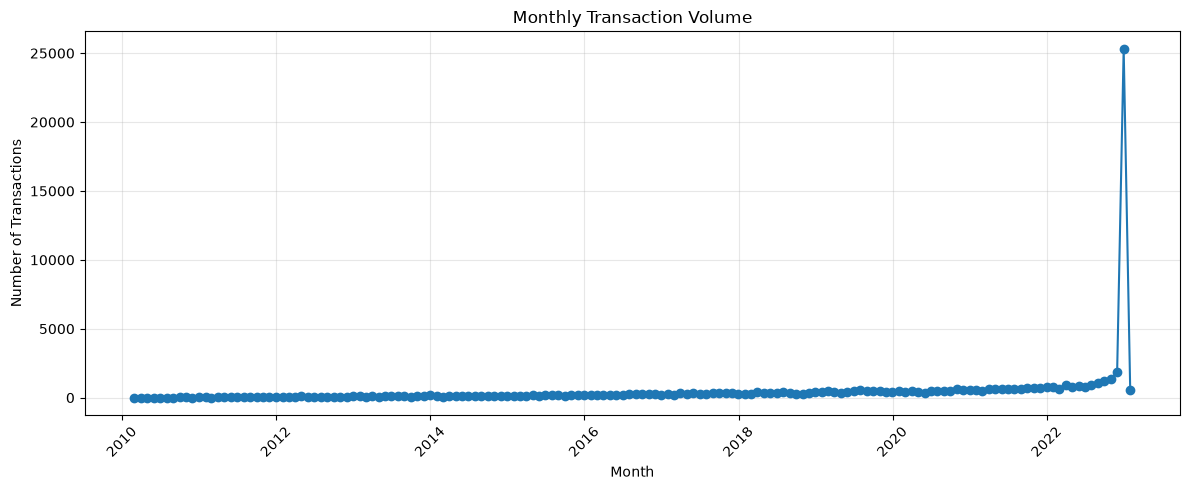

In [34]:
#Analise da tendência das transações ao longo do periodo mensal (quantidade de transações por mês)
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_transactions["data_transacao"],
    monthly_transactions["transaction_count"],
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [35]:
#Observações:
    #Em 12-2022 houve um aumento não homogeneo das transações, para tanto será necessário investigar melhor essa tendência
    #Nota-se que foram 25319 transações em 12-2022 contra 1841 em 11-2022 -> ~1275% de aumento aproximadamente

#Recomendação: 
    #Será necessário entender esse pico anômalo de 2022

In [36]:
#Analise das 10 maiores transações diárias
daily_transactions: pd.DataFrame = (
    new_datasets["transacoes"]
    .set_index("data_transacao")
    .resample("D")
    .agg(
        transaction_count=("cod_transacao", "count"),
        total_transaction_value=("valor_transacao", "sum")
    )
    .reset_index()
)

daily_transactions.sort_values(
    "transaction_count",
    ascending=False
).head(10)

,data_transacao,transaction_count,total_transaction_value
4688,2022-12-29 00:00:00+00:00,13825,2789538.75
4689,2022-12-30 00:00:00+00:00,6612,1028842.34
4687,2022-12-28 00:00:00+00:00,690,88925.03
4686,2022-12-27 00:00:00+00:00,474,256967.87
4685,2022-12-26 00:00:00+00:00,313,261488.79
4684,2022-12-25 00:00:00+00:00,289,96972.19
4683,2022-12-24 00:00:00+00:00,277,9209.08
4682,2022-12-23 00:00:00+00:00,204,-14323.19
4680,2022-12-21 00:00:00+00:00,200,23825.41
4681,2022-12-22 00:00:00+00:00,199,28246.41


In [37]:
#Observações:
    #Basicamente as 10 maiores quantidade de transações diárias ocorrem nos ultimos dias de 12-2022

#Recomendação: 
    #Será necessário complementar com o valor das transações para entender se a tendência se repete

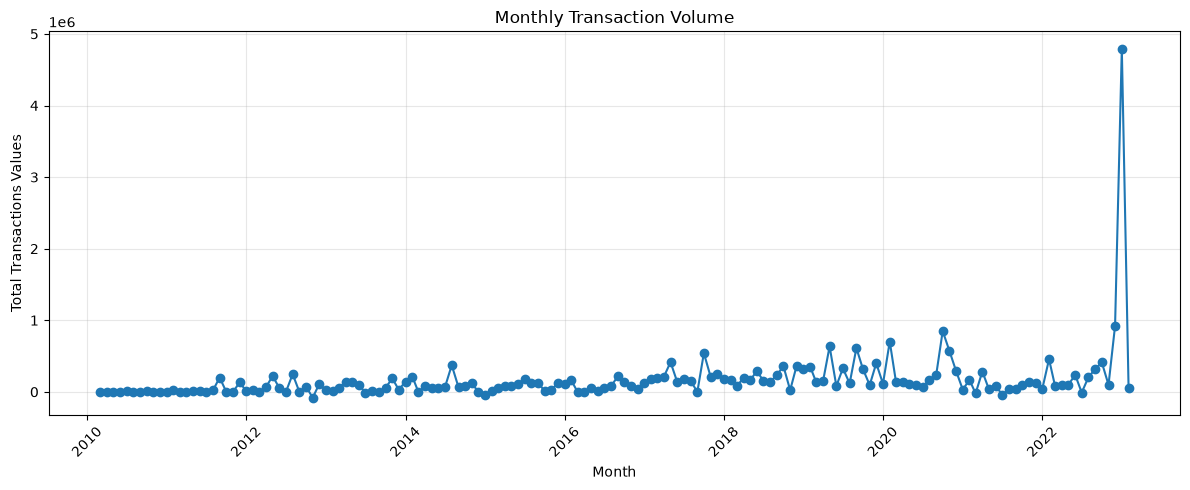

In [38]:
#Analise da tendência das transações ao longo do periodo mensal (valor de transações por mês)
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_transactions["data_transacao"],
    monthly_transactions["total_transaction_value"],
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Total Transactions Values")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [39]:
#Observações:
    #Aproximadamente 80% de todas as 25319 transações de 12-2022 ocorreram em apenas dois dias (29 e 30)
    #A concentração também se reflete no valor financeiro transacionado, caracterizando um comportamento atípico no período

#Recomendação: 
    #Investigar quais tipos de transação e quais clientes/contas foram responsáveis pelo pico de 12-2022
    #Será tomado como base os dias 29 e 30 de 12-2022, por serem significativamente quase toda a amostra

In [40]:
#Analise dos dias 29 e 30 de dezembro por tipo de transações realizadas
peak_transactions: pd.DataFrame = (
    new_datasets["transacoes"]
    .loc[
        new_datasets["transacoes"]["data_transacao"].dt.date.isin(
            [
                pd.Timestamp("2022-12-29").date(),
                pd.Timestamp("2022-12-30").date()
            ]
        )
    ]
    .assign(
        transaction_date=lambda df: df["data_transacao"].dt.date
    )
    .groupby(
        ["transaction_date", "nome_transacao"]
    )
    .agg(
        transaction_count=("cod_transacao", "count"),
        total_transaction_value=("valor_transacao", "sum")
    )
    .sort_values(
        ["transaction_date", "transaction_count"],
        ascending=[True, False]
    )
    .reset_index()
)

display(peak_transactions)

,transaction_date,nome_transacao,transaction_count,total_transaction_value
0,2022-12-29,Compra Crédito,4053,-221967.77
1,2022-12-29,Pix - Realizado,4018,-2087094.00
2,2022-12-29,Compra Débito,2751,-149609.70
3,2022-12-29,Pix - Recebido,1543,913927.90
4,2022-12-29,Depósito em espécie,514,32402.91
5,2022-12-29,Saque,497,-139220.00
6,2022-12-29,TED - Recebido,100,3233050.00
7,2022-12-29,Pagamento de boleto,78,-85972.00
8,2022-12-29,Transferência entre CC - Crédito,59,36072.60
9,2022-12-29,DOC - Recebido,54,2027660.00


In [41]:
#Observações:
    #O pico de 29 e 30 de 12-2022 foi concentrado principalmente em PIX, compras no crédito e débito, com forte predominância de operações em 29/12/22
    #Em valor financeiro, TED e DOC recebidos apresentaram impacto desproporcional ao volume de operações.

#Recomendação:  
    #Investigar a concentração dessas operações por cliente e conta 
    #Identificar quais participantes foram responsáveis pelo comportamento atípico

In [42]:
#Analise das 10 maiores transações diárias por tipo de conta de cliente nos dias 29 e 30 de 12-2022 (quantidade de transações)
peak_accounts: pd.DataFrame = (
    new_datasets["transacoes"]
    .loc[
        new_datasets["transacoes"]["data_transacao"].dt.date.isin(
            [
                pd.Timestamp("2022-12-29").date(),
                pd.Timestamp("2022-12-30").date()
            ]
        )
    ]
    .groupby("num_conta")
    .agg(
        transaction_count=("cod_transacao", "count"),
        total_transaction_value=("valor_transacao", "sum")
    )
    .sort_values("transaction_count", ascending=False)
    .reset_index()
)

peak_accounts.head(10)

,num_conta,transaction_count,total_transaction_value
0,754,87,-269.58
1,180,86,2755.09
2,687,86,42641.15
3,9,75,75739.07
4,686,75,9409.67
5,422,75,-83.34
6,844,74,16469.86
7,670,74,40315.50
8,538,74,2401.90
9,939,73,-6296.06


In [43]:
#Observações:
    #O aumento de volume em 29 e 30 de 12-2022 parece ter sido distribuído entre várias contas, e não provocado por uma única conta dominante

#Recomendação:  
    #Investigar o valor acumulativo e aumentar a amostra para 20

In [44]:
#Analise cumulativa das 20 primeiras contas bancarias ordenadas pelo total do valor investido e o acumulativo da quantidade de transações
peak_accounts = peak_accounts.sort_values(
    "total_transaction_value",
    ascending=False
).reset_index(drop=True)

peak_accounts["cumulative_transaction_count"] = (
    peak_accounts["transaction_count"].cumsum()
)

total_peak_transactions: int = peak_accounts["transaction_count"].sum()

peak_accounts["cumulative_share"] = (
    peak_accounts["cumulative_transaction_count"]
    / total_peak_transactions
)

peak_accounts.head(20)

,num_conta,transaction_count,total_transaction_value,cumulative_transaction_count,cumulative_share
0,18,49,203726.68,49,0.002398
1,338,29,178566.68,78,0.003817
2,197,35,163506.82,113,0.005529
3,484,19,148649.15,132,0.006459
4,426,58,139682.20,190,0.009297
5,411,54,139588.09,244,0.011939
6,56,54,138884.71,298,0.014581
7,499,60,130015.80,358,0.017517
8,597,32,108289.73,390,0.019083
9,101,8,104704.78,398,0.019474


In [45]:
#Observações:
    #Valor financeiro e quantidade de transações não estão diretamente relacionados nesses dois dias
    #A conta 484, por exemplo, movimentou R$ 148,6 mil com apenas 19 operações, enquanto a conta 426 fez 58 operações e movimentou R$ 139,7 mil.

In [46]:
#Analise cumulativa das 20 primeiras contas bancarias ordenadas pelo total do valor investido e o acumulativo do valor das transações
peak_accounts["cumulative_transaction_value"] = (
    peak_accounts["total_transaction_value"].cumsum()
)

total_peak_value: float = (
    peak_accounts["total_transaction_value"].sum()
)

peak_accounts["cumulative_value_share"] = (
    peak_accounts["cumulative_transaction_value"]
    / total_peak_value
)

peak_accounts.head(20)

,num_conta,transaction_count,total_transaction_value,cumulative_transaction_count,cumulative_share,cumulative_transaction_value,cumulative_value_share
0,18,49,203726.68,49,0.002398,203726.68,0.053354
1,338,29,178566.68,78,0.003817,382293.36,0.100119
2,197,35,163506.82,113,0.005529,545800.18,0.142940
3,484,19,148649.15,132,0.006459,694449.33,0.181870
4,426,58,139682.20,190,0.009297,834131.53,0.218452
5,411,54,139588.09,244,0.011939,973719.62,0.255008
6,56,54,138884.71,298,0.014581,1112604.33,0.291381
7,499,60,130015.80,358,0.017517,1242620.13,0.325431
8,597,32,108289.73,390,0.019083,1350909.86,0.353791
9,101,8,104704.78,398,0.019474,1455614.64,0.381213


In [47]:
#Observações:
    #R$ 2311516,78 são referentes a apenas 20 contas que representam o pico do grafico, equivalente a 60,54% de todo o valor transacionado no pico
    #Essas mesmas 20 contas representam apenas 737 transações, ou 3,61% do volume de operações
    #O pico em 29 e 30 de 12-2022 é amplamente distribuído em quantidade de operações, mas significativamente concentrado em valor financeiro
    #Esses dois dias representam um marco histórico nas operações de transações com uma grande concentração de valores monetários distribuidos em poucas contas

In [48]:
#Insights:
    #As 20 contas com maior valor transacionado nos dias 29 e 30 de 12-2022 concentraram 60,54% do valor financeiro, 
    #embora representassem apenas 3,61% das transações realizadas no período.
    #Esse resultado indica que o pico apresentou baixa concentração em volume de operações, mas alta concentração financeira, 
    #sugerindo a existência de contas com operações de maior valor que contribuíram de forma relevante para o movimento observado

    #No final isso pode exemplificar um marco histórico, como as eleições de 2022, que moveram altos investimentos bancários de débito e PIX
    #ou um movimento de geração de dados proposital que pode ser classificado como um achado técnico anômalo

#Recomendação:
    #Investigar essas contas sob a perspectiva de perfil dos clientes e tipos de transação, buscando identificar os fatores associados à concentração financeira

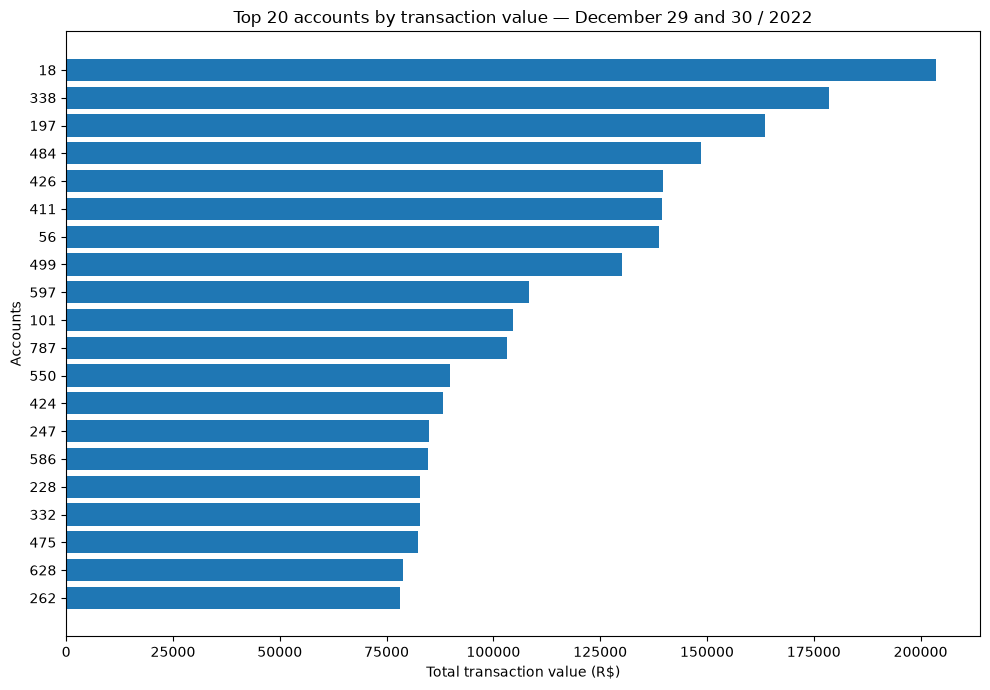

In [49]:
#Visualização gráfica das 20 maiores contas com valor financeiro transacionado durante o período de pico.
top_accounts: pd.DataFrame = (
    peak_accounts
    .nlargest(20, "total_transaction_value")
    .sort_values("total_transaction_value")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_accounts["num_conta"].astype(str),
    top_accounts["total_transaction_value"]
)

plt.xlabel("Total transaction value (R$)")
plt.ylabel("Accounts")
plt.title("Top 20 accounts by transaction value — December 29 and 30 / 2022")

plt.tight_layout()
plt.show()

In [50]:
#Será analisado agora:
    #Se o crescimento transacional observado em 2022 pode estar relacionado à mudança no comportamento de uso dos clientes 
    #E à adoção de novos meios de pagamento e plataformas digitais, especialmente o PIX
    #Quando foi adotado agências digitais e se isso impacta os dados

#Função para analise temporal entre clientes, contas, agências e transações
transaction_profile: pd.DataFrame = analytic.analyze_transaction_profile(
    new_datasets["transacoes"],
    new_datasets["contas"],
    new_datasets["clientes"],
    new_datasets["agencias"]
)

transaction_profile.head()

#Agrupano pela quantidade de transações -> Representa a quantidade de vezes que foi usada
transaction_profile.sort_values(
    "transaction_count",
    ascending=False
).reset_index(drop=True).head(10)

,transaction_month,tipo_cliente,tipo_agencia,nome_transacao,transaction_count,total_transaction_value
0,2022-12,PF,Digital,Compra Crédito,3883,-212266.44
1,2022-12,PF,Digital,Pix - Realizado,3865,-2018164.40
2,2022-12,PF,Física,Pix - Realizado,3539,-1834312.10
3,2022-12,PF,Física,Compra Crédito,3465,-190724.13
4,2022-12,PF,Digital,Compra Débito,2724,-156518.29
5,2022-12,PF,Física,Compra Débito,2401,-126464.43
6,2022-12,PF,Digital,Pix - Recebido,1503,900412.30
7,2022-12,PF,Física,Pix - Recebido,1307,769665.80
8,2022-12,PF,Digital,Depósito em espécie,510,33179.02
9,2022-12,PF,Digital,Saque,481,-127060.00


In [51]:
#Observações:
    #O pico de dezembro de 2022 foi predominantemente composto por transações de clientes PF (natural, pois só há clientes PF no dataset)
    #O pico apresentou forte participação de operações associadas ao canal digital (agência digitais), especialmente PIX

In [52]:
#Analise da evolução mensal do tipo de agência
channel_evolution: pd.DataFrame = analytic.prepare_channel_evolution(
    transaction_profile
)

channel_evolution.sort_values(
    "transaction_count",
    ascending=False
).reset_index(drop=True).head(10)

,transaction_month,tipo_agencia,transaction_count
0,2022-12,Digital,13394
1,2022-12,Física,11925
2,2022-11,Digital,949
3,2022-11,Física,892
4,2022-10,Digital,726
5,2022-10,Física,646
6,2022-09,Física,619
7,2022-09,Digital,611
8,2022-08,Digital,568
9,2022-03,Física,555


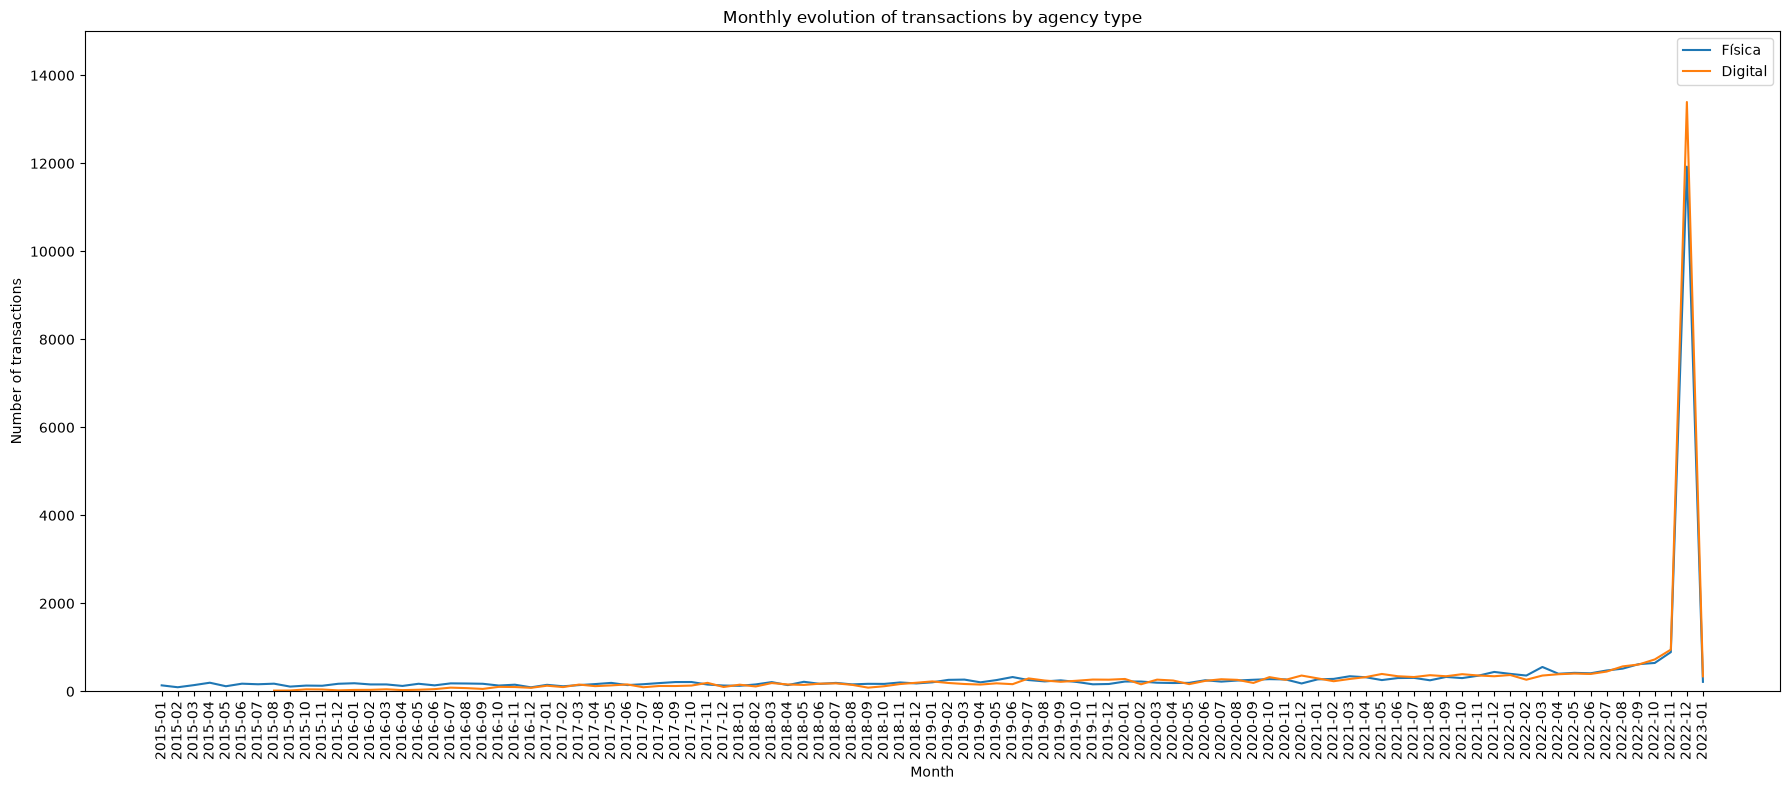

In [61]:
#Análise gráfica da evolução mensal das transações por tipo de agência
plt.figure(figsize=(18, 8))
for channel_type in channel_evolution["tipo_agencia"].unique():
    channel_data: pd.DataFrame = (
        channel_evolution[
            channel_evolution["tipo_agencia"] == channel_type
        ]
    )

    channel_data: pd.DataFrame = (
        channel_evolution[
            (channel_evolution["tipo_agencia"] == channel_type)
            & (channel_evolution["transaction_month"] >= "2015-01")
        ]
    )

    plt.plot(
        channel_data["transaction_month"].astype(str),
        channel_data["transaction_count"],
        label=channel_type
    )

plt.xlabel("Month")
plt.ylabel("Number of transactions")
plt.title("Monthly evolution of transactions by agency type")

#Limita a escala para facilitar a visualização dos meses anteriores ao pico de 2022
plt.ylim(0, 15000)

plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
#Observação:
    #Dezembro de 2022 apresenta um pico excepcional de transações, superior à escala utilizada no gráfico 
    #A adoção das agências digitais ocorreu em 08-2015, sendo que o número de transações se manteve pareado com as físicas,
    #porém no pico de 12-2022 o número de transações das agências digitais ultrapassou em mais 2000 o número das físicas

In [55]:
#Analise da evolução mensal por tipo de transação dando ênfase no PIX
pix_evolution: pd.DataFrame = analytic.prepare_pix_evolution(
    transaction_profile
)

pix_evolution.sort_values(
    "transaction_count",
    ascending=False
).reset_index(drop=True).head(10)

,transaction_month,transaction_group,transaction_count
0,2022-12,Demais transações,15052
1,2022-12,Pix,10267
2,2022-11,Demais transações,1092
3,2022-10,Demais transações,820
4,2022-11,Pix,749
5,2022-09,Demais transações,743
6,2022-08,Demais transações,671
7,2020-10,Demais transações,602
8,2022-03,Demais transações,571
9,2019-07,Demais transações,552


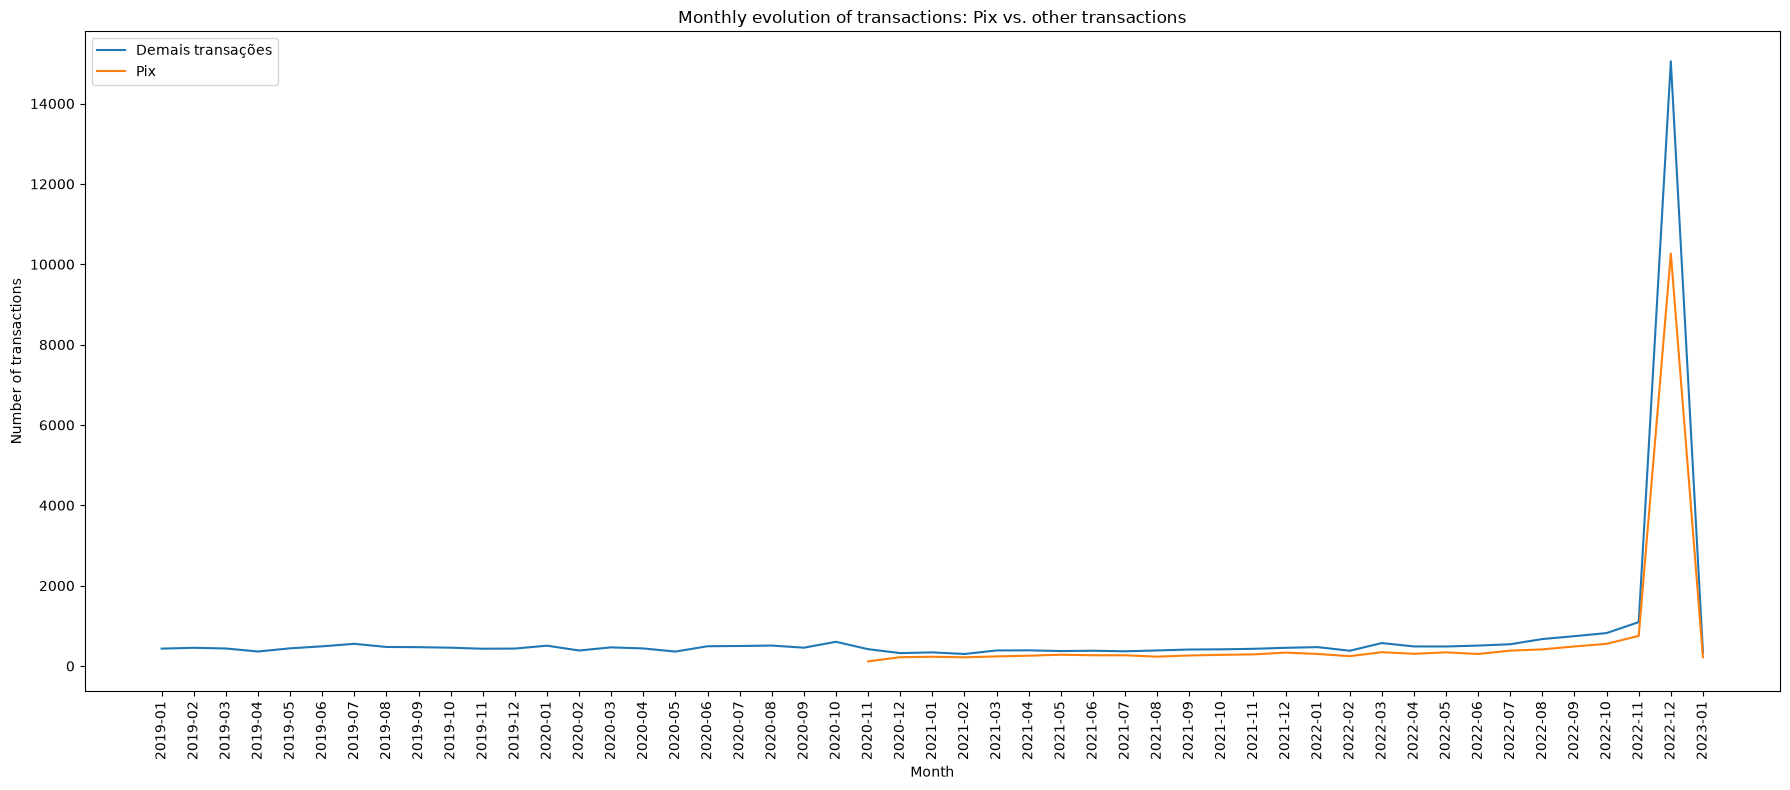

In [ ]:
#Análise gráfica da evolução mensal por tipo de transação dando ênfase no PIX
plt.figure(figsize=(18, 8))
for transaction_group  in pix_evolution["transaction_group"].unique():
    group_data: pd.DataFrame = (
        pix_evolution[
            pix_evolution["transaction_group"] == transaction_group 
        ]
    )

    group_data: pd.DataFrame = (
        pix_evolution[
            (pix_evolution["transaction_group"] == transaction_group )
            & (pix_evolution["transaction_month"] >= "2019-01")
        ]
    )

    plt.plot(
        group_data["transaction_month"].astype(str),
        group_data["transaction_count"],
        label=transaction_group 
    )

plt.xlabel("Month")
plt.ylabel("Number of transactions")
plt.title("Monthly evolution of transactions: PIX vs. other transactions")


plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
#Observações:
    #A análise temporal indica a introdução das transações PIX a partir de 11-2020, 
    #com crescimento e manutenção de um volume relevante de operações ao longo do período analisado
    #Embora o PIX permaneça abaixo do conjunto das demais modalidades, sua participação torna-se expressiva quando considerada individualmente

    #No pico transacional de 12-2022, foram registradas 10267 operações PIX, 
    #correspondendo a aproximadamente 40,6% das 25319 transações realizadas no mês. As demais modalidades, somadas, representaram 15052 operações

    #O resultado sugere que o PIX passou a representar uma parcela importante da atividade transacional do BanVic nesse periodo
    #Entretanto, os dados analisados não permitem atribuir o pico de dezembro exclusivamente à adoção do PIX, 
    #sendo necessário considerar também o comportamento das demais modalidades

## Dataset rows quarantine

In [58]:
#Seção criada a partr da análise de que a conta 528 foi considerada anômala e precisaria ser segregada
#Aqui é possivel definir outras contas para segregar
anomalous_account_ids: list[int] = [528]

#Função que irá gerar uma coluna de flag para identificar contas anômalas e futuramente separa-las no power BI
new_datasets["contas"] = analytic.flag_anomalous_accounts(
    new_datasets["contas"],
    anomalous_account_ids
)

## New dataset generated

In [59]:
#Chamando função principal para gerar os novos datasets CSVs já tratados a partir dos arquivos CSVs antigos
func.save_csv_files(new_datasets, NEW_DATASET_DIR)